In [1]:
print("과제 1")

과제 1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("해당 라이브러리들의 용도 : ")
print("- pandas: 데이터 분석과 처리")
print("- numpy: 수치 계산")
print("- matplotlib: 시각화")
print("- seaborn: 고급 시각화")
print("- sklearn.datasets: 데이터셋 로드")
print("- sklearn.model_selection: 모델 선택")
print("- sklearn.preprocessing: 데이터 전처리")
print("- sklearn.neighbors: K-최근접 이웃 알고리즘")
print("- sklearn.metrics: 모델 평가")

해당 라이브러리들의 용도 : 
- pandas: 데이터 분석과 처리
- numpy: 수치 계산
- matplotlib: 시각화
- seaborn: 고급 시각화
- sklearn.datasets: 데이터셋 로드
- sklearn.model_selection: 모델 선택
- sklearn.preprocessing: 데이터 전처리
- sklearn.neighbors: K-최근접 이웃 알고리즘
- sklearn.metrics: 모델 평가


In [3]:
data = load_iris(as_frame=True)

df = data.frame.copy()
df["species"] = df["target"].map(dict(enumerate(data.target_names)))

X = data.data
y = data.target

print("데이터 크기:", X.shape)
print("클래스 이름:", data.target_names)
print("클래스 분포:")
print(df["species"].value_counts())

데이터 크기: (150, 4)
클래스 이름: ['setosa' 'versicolor' 'virginica']
클래스 분포:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
print(df[data.feature_names].describe())

print(df.groupby("species")[data.feature_names].mean().round(2))

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01           

In [9]:
print(df[data.feature_names].describe())

print(df.groupby("species")[data.feature_names].mean().round(2))

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01           

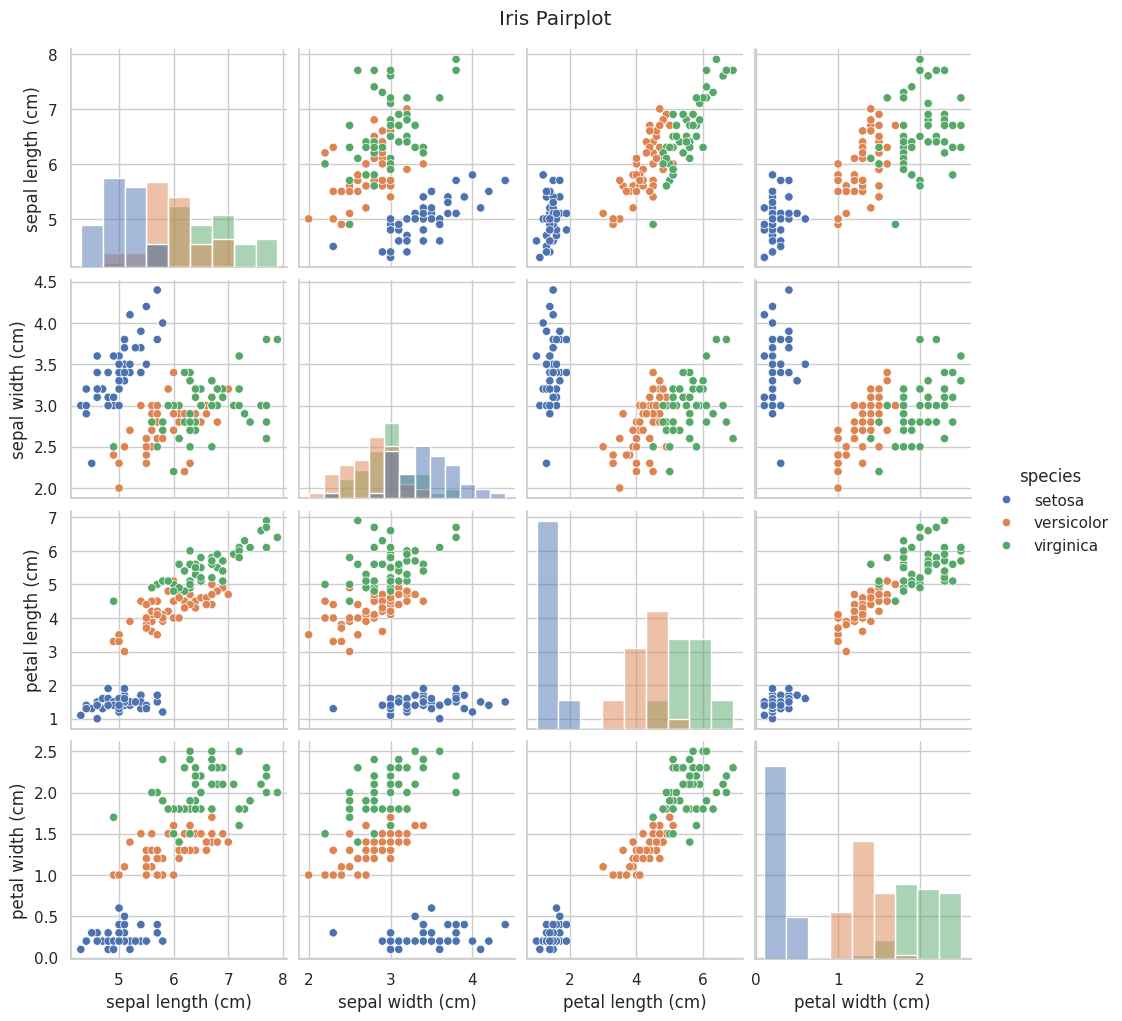

In [10]:
sns.set_theme(style="whitegrid")

pair = sns.pairplot(
    df,
    vars=data.feature_names,
    hue="species",
    diag_kind="hist"
)

pair.fig.suptitle("Iris Pairplot", y=1.02)
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("학습 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

학습 데이터 크기: (105, 4)
테스트 데이터 크기: (45, 4)


In [12]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("표준화된 학습 데이터 일부:")
print(X_train_std[:5])

표준화된 학습 데이터 일부:
[[-0.90045861 -1.22024754 -0.4419858  -0.13661044]
 [ 0.38036614 -1.87955796  0.40282929  0.38029394]
 [-0.90045861  1.63676428 -1.2868009  -1.17041921]
 [ 1.07899781  0.31814344  1.19132338  1.41410271]
 [-0.20182693 -0.56093712  0.17754527  0.12184175]]


In [13]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 1.66119088, -0.34116698,  1.41660741,  0.76797223],
       [ 0.26392752, -0.34116698,  0.51547131,  0.25106784],
       [ 0.49680475, -0.56093712,  0.74075533,  0.38029394],
       [ 0.49680475,  0.53791358,  0.51547131,  0.50952003],
       [ 0.26392752, -0.12139684,  0.62811332,  0.76797223],
       [ 0.9625592 ,  0.0983733 ,  1.02236036,  1.5433288 ],
       [-0.43470415, -1.65978782,  0.12122426,  0.12184175],
       [-0.31826554, -1.22024754,  0.06490325, -0.13661044],
       [-0.55114277,  0.75768372, -1.17415888, -1.29964531],
       [ 1.19543642,  0.0983733 ,  0.74075533,  1.41410271],
       [-0.08538832,  2.07630456, -1.45576392, -1.29964531],
       [-1.7155289 , -0.12139684, -1.39944291, -1.29964531],
       [ 0.9625592 , -1.22024754,  1.13500238,  0.76797223],
       [ 0.72968197, -0.12139684,  0.96603936,  0.76797223],
       [-0.78401999,  0.75768372, -1.3431219 , -1.29964531],
       [ 0.38036614,  0.75768372,  0.90971835,  1.41410271],
       [-1.13333583, -1.

In [14]:
neighbors = range(1, 16)

train_acc = []
test_acc = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)

    train_acc.append(knn.score(X_train_std, y_train))
    test_acc.append(knn.score(X_test_std, y_test))

print("각 k별 테스트 정확도:")
for k, score in zip(neighbors, test_acc):
    print(f"k={k:2d} -> {score:.4f}")

best_k = list(neighbors)[int(np.argmax(test_acc))]
print("선택한 최적 k:", best_k)

각 k별 테스트 정확도:
k= 1 -> 0.9333
k= 2 -> 0.8889
k= 3 -> 0.9111
k= 4 -> 0.9111
k= 5 -> 0.9111
k= 6 -> 0.9111
k= 7 -> 0.9333
k= 8 -> 0.9111
k= 9 -> 0.9556
k=10 -> 0.9333
k=11 -> 0.9556
k=12 -> 0.9556
k=13 -> 0.9333
k=14 -> 0.9556
k=15 -> 0.9333
선택한 최적 k: 9


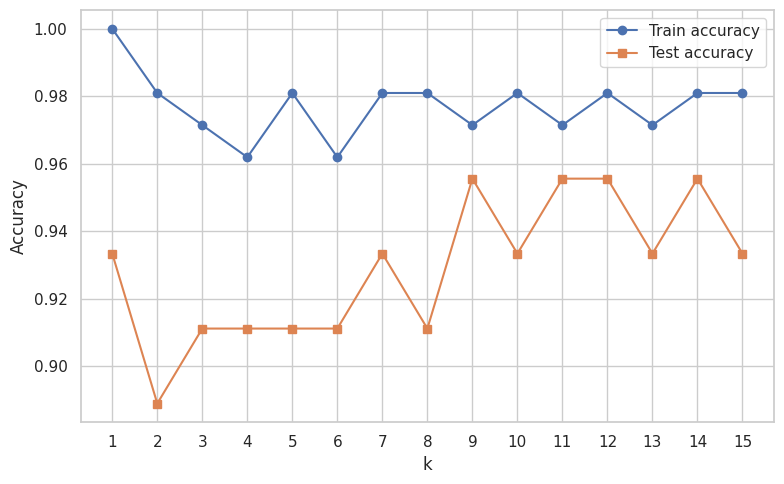

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(list(neighbors), train_acc, marker="o", label="Train accuracy")
plt.plot(list(neighbors), test_acc, marker="s", label="Test accuracy")

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(list(neighbors))
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_std, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
y_pred = knn_best.predict(X_test_std)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("최종 정확도:", round(acc, 4))
print("혼동행렬:")
print(cm)

print("분류 보고서:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

최종 정확도: 0.9556
혼동행렬:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]
분류 보고서:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [18]:
new_sample = pd.DataFrame(
    [[5.7, 2.9, 4.2, 1.3]],
    columns=data.feature_names
)

new_sample_std = scaler.transform(new_sample)
new_pred = knn_best.predict(new_sample_std)
new_prob = knn_best.predict_proba(new_sample_std)

print("새 샘플:", new_sample.values.tolist()[0])
print("예측 품종:", data.target_names[new_pred[0]])
print("클래스별 확률:", new_prob)

새 샘플: [5.7, 2.9, 4.2, 1.3]
예측 품종: versicolor
클래스별 확률: [[0. 1. 0.]]
